# Exemplo 3 — fatores fracionários e setor específico

Reprodução auditada do Exemplo 3 da planilha oficial. Cada contraparte é influenciada por quatro fatores e seus pesos somam 100%. A banda de severidade usa a exposição total; somente a intensidade de default é repartida entre fatores.

In [1]:
# Imports do pacote a partir da raiz do projeto.
import sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from creditriskplus import data
from creditriskplus.simple_model import calculate_loss_distribution_detailed

portfolio = data.create_example_3_4sector_portfolio()
sector_columns = [c for c in portfolio if c.startswith('sector_weight_')]
specific_index = sector_columns.index('sector_weight_Specific')
assert np.allclose(portfolio[sector_columns].sum(axis=1), 1.0)
display(portfolio.head())

,obligor_id,exposure,rating,mean_default_rate,std_default_rate,sector_weight_Specific,sector_weight_US,sector_weight_Japan,sector_weight_Europe
0,1,358475,H,0.30,0.150,0.50,0.30,0.10,0.10
1,2,1089819,H,0.30,0.150,0.25,0.25,0.25,0.25
2,3,1799710,F,0.10,0.050,0.25,0.25,0.20,0.30
3,4,1933116,G,0.15,0.075,0.75,0.05,0.10,0.10
4,5,2317327,G,0.15,0.075,0.50,0.10,0.10,0.30


## Tratamento do setor específico

A Seção A12.3 determina que o setor específico conserve a média $\mu_s=\sum_A\theta_{As}\varepsilon_A/\nu_A$, mas tenha $\sigma_s=0$. Pela Seção A11, sua PGF converge ao caso Poisson. Uma NB individual com $\alpha=4$ acrescentaria volatilidade não prescrita e não reproduz a planilha.

In [2]:
# Uma única chamada calcula os quatro setores e os combina por convolução.
result = calculate_loss_distribution_detailed(
    portfolio.exposure, portfolio.mean_default_rate, portfolio.std_default_rate,
    np.zeros(len(portfolio)),
    sector_weights_matrix=portfolio[sector_columns].to_numpy(),
    idiosyncratic_sector_indices=[specific_index],
    max_loss_dollars=150_000_000,
)

sector_table = pd.DataFrame([vars(p) for p in result.sector_parameters], index=sector_columns)
display(sector_table)
assert sector_table.loc['sector_weight_Specific', 'std_defaults'] == 0
assert result.tail_mass_upper_bound < 1e-8

,mean_defaults,std_defaults,expected_loss_units,alpha,beta,negative_binomial_p
sector_weight_Specific,1.299482,0.000000,32.056953,inf,0.000000,0.000000
sector_weight_US,0.559089,0.279544,11.481786,4.0,0.139772,0.122632
sector_weight_Japan,0.431004,0.215502,8.988833,4.0,0.107751,0.097270
sector_weight_Europe,0.844787,0.422393,17.742372,4.0,0.211197,0.174370


In [3]:
# O XLS interpola a grade; o VaR matemático permanece discreto.
reference_el = 14_221_863.0
reference_var99 = 47_368_235.0
comparison = pd.DataFrame({
    'Métrica': ['EL', 'VaR 99% interpolado (XLS)', 'VaR 99% discreto'],
    'Python': [result.expected_loss, result.quantile(.99, interpolate=True), result.quantile(.99)],
    'Referência': [reference_el, reference_var99, np.nan],
})
comparison['Diferença'] = comparison.Python - comparison.Referência
display(comparison.round(3))
assert abs(result.expected_loss-reference_el) < 1
assert abs(result.quantile(.99, interpolate=True)-reference_var99) < 1

,Métrica,Python,Referência,Diferença
0,EL,1.422186e+07,14221863.0,0.481
1,VaR 99% interpolado (XLS),4.736823e+07,47368235.0,-0.328
2,VaR 99% discreto,4.756142e+07,NaN,NaN


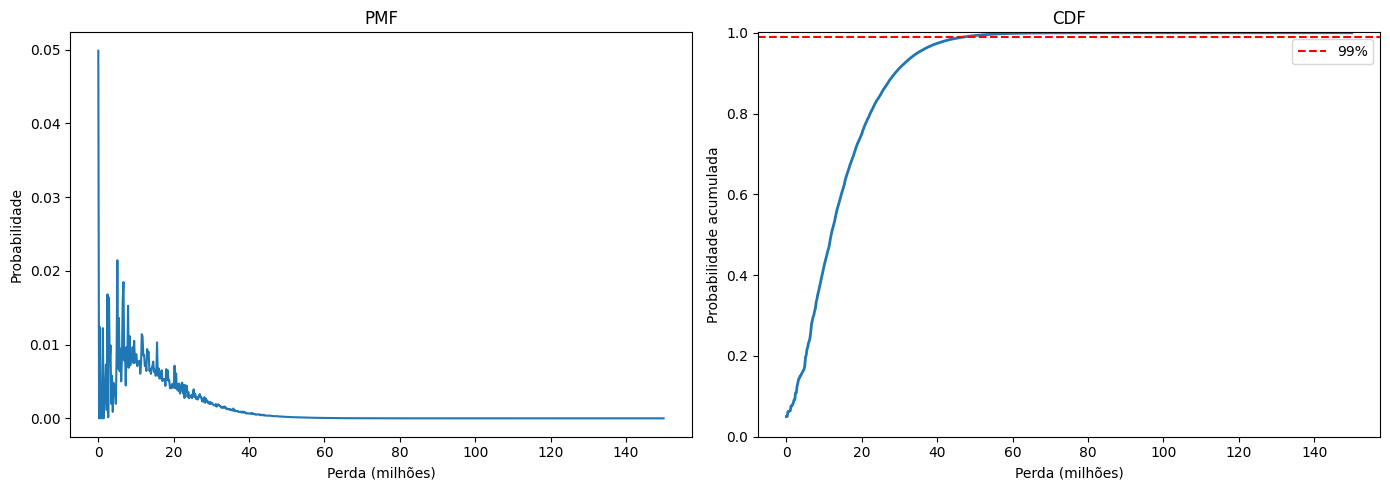

In [4]:
# PMF e CDF da perda total.
losses = np.arange(len(result.pmf))*result.unit_size
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(losses/1e6, result.pmf, lw=1.5)
axes[0].set(xlabel='Perda (milhões)', ylabel='Probabilidade', title='PMF')
axes[1].plot(losses/1e6, result.cdf, lw=2)
axes[1].axhline(.99, color='red', ls='--', label='99%')
axes[1].set(xlabel='Perda (milhões)', ylabel='Probabilidade acumulada', title='CDF', ylim=(0, 1.001))
axes[1].legend(); plt.tight_layout(); plt.show()

## Resultado

A aplicação literal de A11–A12.3 elimina a divergência histórica de 0,579%: EL e VaR interpolado reproduzem o XLS com diferença inferior a uma unidade monetária. A massa truncada é reportada e não foi normalizada.